# Fit one object

In [1]:
from AllModelFunctions import *
import sys
sys.path.append('/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject')
from functions import import_spectra


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from PyAstronomy import pyasl
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from datetime import date

### Parameters

In [2]:
object_name = 'Vela X-1'
object_ = object_name_to_save_name(object_name)

galaxy = 'Milkyway'
vsini_best = 126

today = date.today()
save_path = f'/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject/Plots/{object_}/'

### Import spectra & models

In [3]:
spectra = import_spectra(object_)
models = import_models_quickload(galaxy)

Spectrum for LMCX_4 is FLUX REDUCED


### Determine radial velocity of the object

The velocity of the object is: 314.8953368544094 +- 18.32468455723802


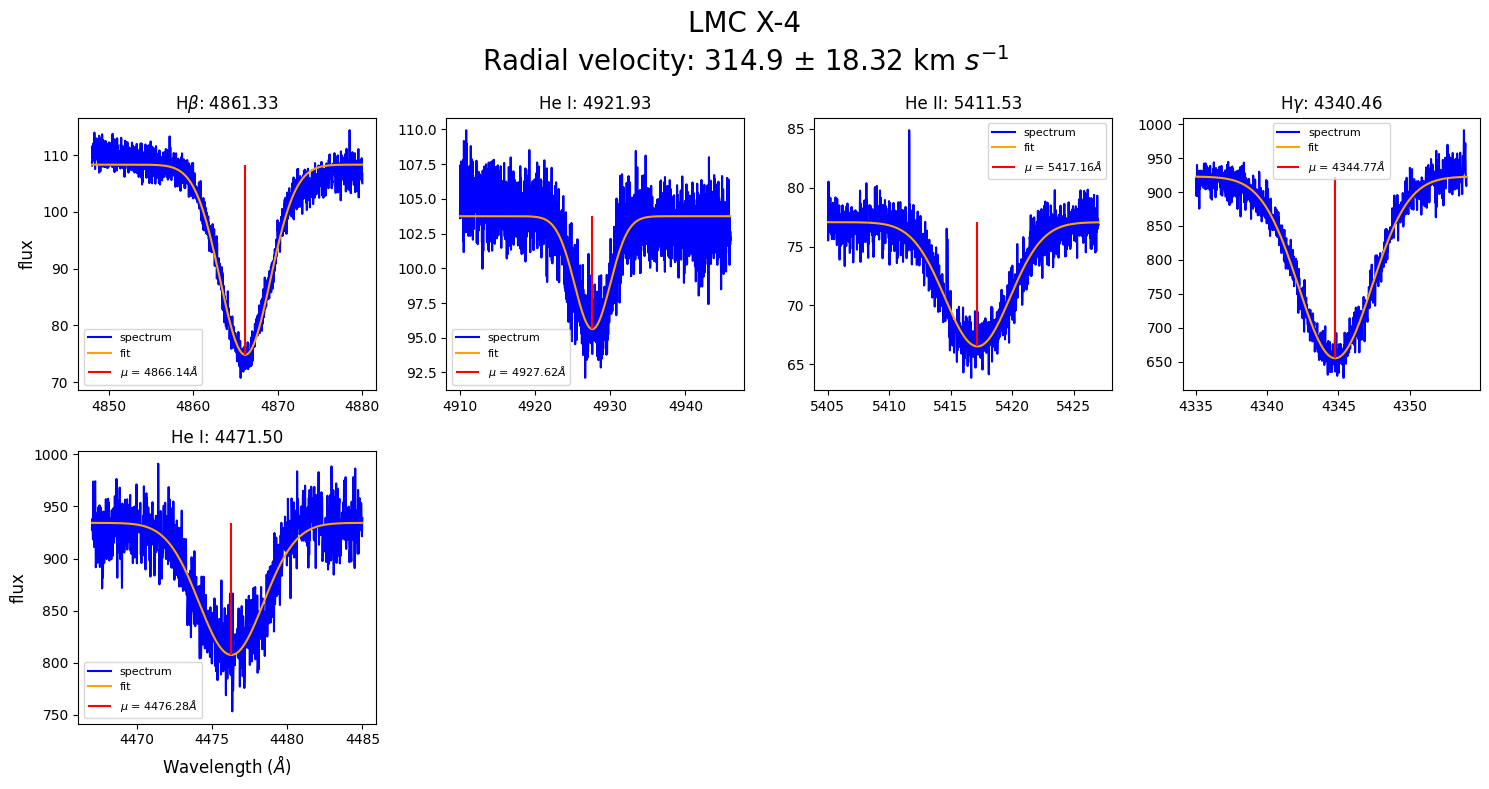

The radial velocities are:
[296.8806564843811, 346.9455007494229, 311.98471505632403, 297.99986552056777, 320.6659464613509]


In [4]:
spectral_lines_doppler = lines_doppler(object_name)
vrad = determine_radial_velocity(spectra, spectral_lines_doppler, gaussian, object_name,
                                              save=(save_path + f'({today})RadialVelocity.png'))

### Do the grid search

In [5]:
spectral_lines_model_fit = lines_model_fit(object_name, vrad)
SNR = SignalToNoise(object_name)
chi2, chi2_perline = chi_squared_for_all_models(spectra, models, spectral_lines_model_fit, SNR=SNR, vrad=vrad, vsini=vsini_best)

Iteration T50000logg4.4DONE

### Grid search analysis

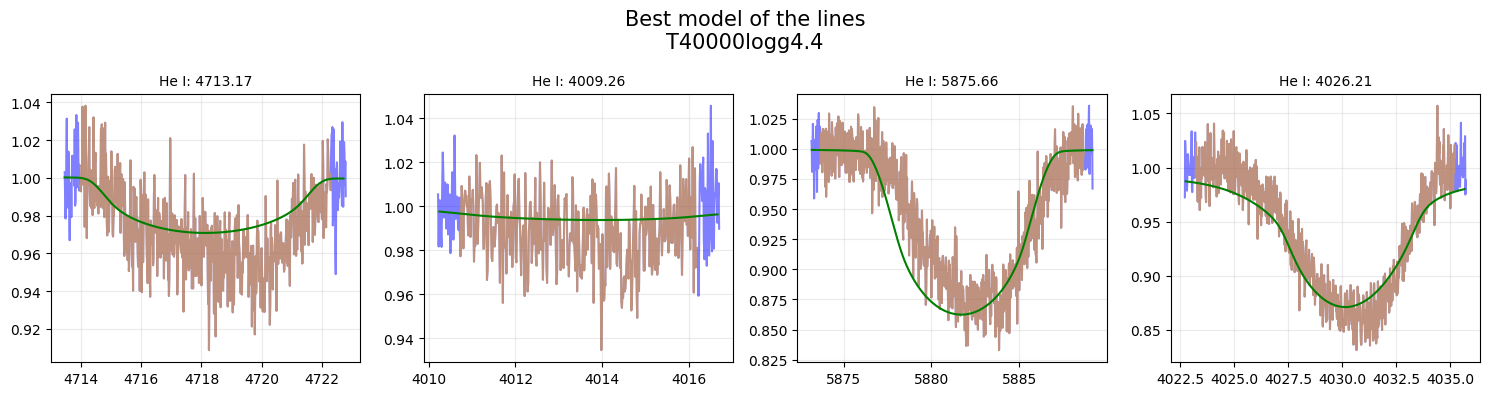

In [6]:
plot_best_model(spectra, models, spectral_lines_model_fit, min(chi2, key=chi2.get), vrad, vsini_best, 
                save=(save_path + f'({today})BestModel.png'))